In [1]:
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X_train = np.array([[2,3],[1,2]])
y_train = np.array([1,-1])

X_test = np.array([[3,3]])

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

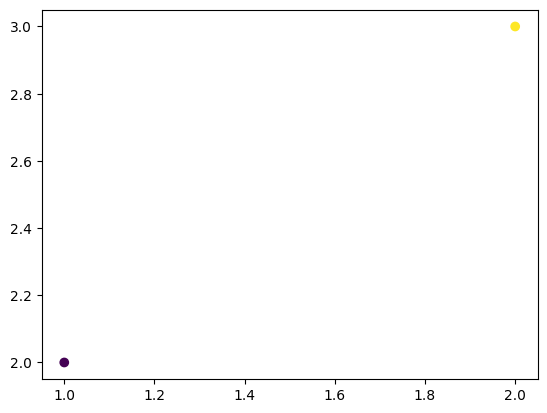

In [3]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
plt

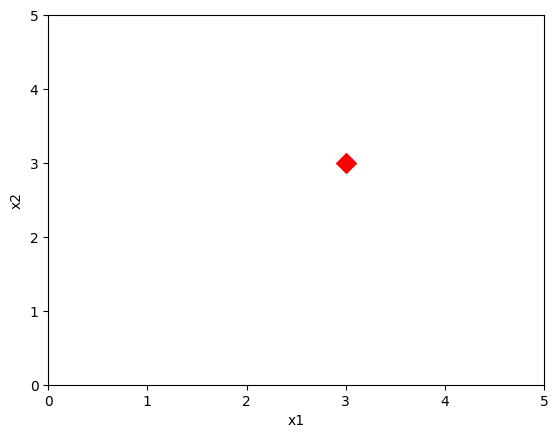

In [5]:
plt.scatter(X_test[:,0], X_test[:,1], c='red',marker='D', s=100)
plt.xlabel('x1')
plt.ylabel('x2')
plt.xlim(0,5)
plt.ylim(0,5)
plt.show()

In [7]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X_train, y_train)

SVC(kernel='linear')

In [12]:
#분류별 서포트벡터의 수
print(clf.n_support_)

#서포트 벡터
print(clf.support_vectors_)

#서포트 벡터 색인
print(clf.support_)

#개체 색인별 분류
print(clf.classes_)

#가중치
print(clf.coef_)

#편향
print(clf.intercept_)

[1 1]
[[1. 2.]
 [2. 3.]]
[1 0]
[-1  1]
[[1. 1.]]
[-4.]


In [13]:
#테스트 데이터 분류
y_pred = clf.predict(X_test)
print(y_pred)

[1]


In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [16]:
data = load_breast_cancer(as_frame=True)
data.frame

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [17]:
#입력부분
data.data

#목표값
print(data.target)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64


In [24]:
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.3,random_state=1234)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(398, 30)
(171, 30)
(398,)
(171,)


In [27]:
scalerX = StandardScaler()
scalerX.fit(X_train)
X_train_std = scalerX.transform(X_train)
X_train_std

array([[-1.53753797, -0.55554819, -1.51985982, ..., -1.73344373,
        -0.77142494,  0.22129607],
       [-0.79609663, -0.38603656, -0.81356785, ..., -0.43011095,
         0.08970515, -0.36303452],
       [ 0.21752653, -0.38603656,  0.18557689, ...,  0.76443594,
         0.80894448, -0.67502531],
       ...,
       [-0.48269225, -0.14686262, -0.46083202, ..., -0.21253919,
         0.1565732 ,  0.16129784],
       [ 1.14079887, -0.12364185,  1.14739725, ...,  0.25197353,
         0.1679897 , -0.23677737],
       [-0.41210568, -1.26610378, -0.43253113, ..., -0.78299078,
        -0.89537548, -0.79241315]])

In [28]:
X_test_std = scalerX.transform(X_test)
X_test_std

array([[-0.70856928,  0.18287232, -0.70200489, ..., -0.5167201 ,
         0.46971142,  0.26564259],
       [-0.95421055, -2.21118915, -0.9661466 , ..., -1.04371727,
        -1.35040445, -0.38703381],
       [-0.48833918, -0.6553975 , -0.38864423, ...,  0.27744681,
         0.51048462,  0.99083859],
       ...,
       [-0.45163416, -0.19330417, -0.51251192, ..., -1.60200162,
        -0.67356925, -1.04857951],
       [-0.45728109, -0.037725  , -0.42678891, ..., -0.34515008,
        -1.29984567, -0.65363464],
       [ 0.58740016,  0.61477866,  0.62239509, ..., -0.16458949,
        -0.29682483, -0.25451598]])

In [30]:
#SVM 분류 모형화: 선형분리
clf = svm.SVC(kernel = 'linear')

#모형학습
clf.fit(X_train_std, y_train)

SVC(kernel='linear')

In [32]:
#테스트 데이터의 분류
y_pred = clf.predict(X_test_std)
print(y_pred)

[1 1 1 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 0 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1
 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1
 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0
 1 0 0 1 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 1 0]


In [33]:
# confusion matrix
cf = confusion_matrix(y_test, y_pred)
print(cf)

[[ 58   8]
 [  1 104]]


In [34]:
clf.score(X_test_std, y_test)

0.9473684210526315